In [1]:
# ------------------------------------------------------------------ #
#  Notebook 02 · RFM Segmentation & K-Means Clustering Validation   #
#  Input : data/processed/retail_clean.parquet                       #
#  Output: data/processed/rfm_segments.parquet                       #
# ------------------------------------------------------------------ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

CLEAN_PATH = r'E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\retail_clean.parquet'
SAVE_PATH  = r'E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\rfm_segments.parquet'

In [2]:
df = pd.read_parquet(CLEAN_PATH)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Reference date for Recency calculation.
# We use one day after the last transaction so the most recent customer gets 1 day, not 0.
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f'Rows           : {len(df):,}')
print(f'Customers      : {df["Customer ID"].nunique():,}')
print(f'Reference date : {reference_date.date()}')

Rows           : 776,872
Customers      : 5,862
Reference date : 2011-12-10


## 1. Compute RFM Metrics

RFM stands for Recency, Frequency, and Monetary Value — three dimensions
that together describe customer behaviour.

- **Recency** : days since the customer's last purchase (lower is better)
- **Frequency** : number of distinct invoices (higher is better)
- **Monetary** : total revenue generated by the customer (higher is better)

Each metric is computed at the customer level from the full transaction history.

In [3]:
# Each customer is reduced to a single row with their three RFM values.
# nunique on Invoice counts distinct orders, not line items.

rfm = (
    df.groupby('Customer ID')
    .agg(
        Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
        Frequency = ('Invoice',     'nunique'),
        Monetary  = ('Revenue',     'sum')
    )
    .reset_index()
)

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f'RFM table shape: {rfm.shape}')
print(f'\nSample:')
rfm.head()

RFM table shape: (5862, 4)

Sample:


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,1658.40
3,12349.0,19,3,3678.69
4,12350.0,310,1,294.40


## 2. RFM Scoring

Each dimension is divided into 5 equal quantile bins and scored 1 to 5.
Recency is scored inversely — a customer who bought recently gets a 5,
not a 1. Frequency and Monetary follow the natural direction (more = better).

The three scores are combined into a single RFM score string (e.g. "555")
which is then mapped to a human-readable segment label.

In [4]:
# Recency: lower days = better, so we reverse the scoring with ascending=False.
# Frequency and Monetary: higher = better, scored normally.

rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Segment mapping based on R and F scores — Monetary refines value but
# recency and frequency are the primary behavioural signals.
def assign_segment(row):
    r, f = row['R_Score'], row['F_Score']
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'
    elif r == 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4:
        return 'Cannot Lose Them'
    elif r == 2 and f <= 2:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print(rfm['Segment'].value_counts())
print(f'\nRFM table shape: {rfm.shape}')
rfm.head()

Segment
Champions              1477
Loyal Customers        1212
Lost                   1084
Hibernating             618
At Risk                 551
Recent Customers        451
Potential Loyalists     380
Cannot Lose Them         89
Name: count, dtype: int64

RFM table shape: (5862, 9)


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,12,77556.46,2,5,5,255,At Risk
1,12347.0,2,8,4921.53,5,4,5,545,Champions
2,12348.0,75,5,1658.40,3,4,4,344,Loyal Customers
3,12349.0,19,3,3678.69,5,3,5,535,Loyal Customers
4,12350.0,310,1,294.40,2,1,2,212,Hibernating


## 3. Segment Visualisation

We look at two things — how many customers are in each segment,
and what the average RFM profile of each segment looks like.
The profile chart validates that our scoring logic is working correctly.

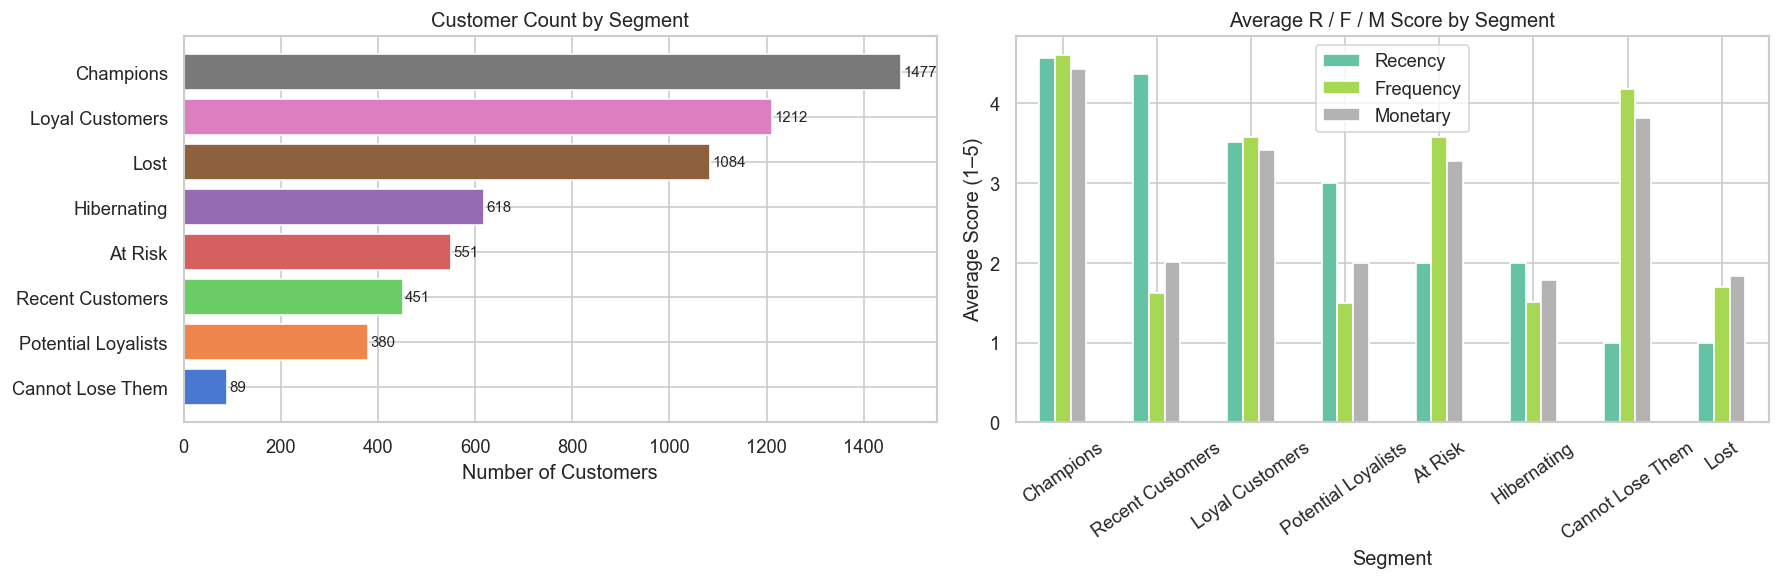

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Segment counts
segment_counts = rfm['Segment'].value_counts().sort_values()
axes[0].barh(
    segment_counts.index,
    segment_counts.values,
    color=sns.color_palette('muted', len(segment_counts))
)
axes[0].set_title('Customer Count by Segment')
axes[0].set_xlabel('Number of Customers')
for i, v in enumerate(segment_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# Average RFM scores per segment — validates the segmentation logic
profile = (
    rfm.groupby('Segment')[['R_Score', 'F_Score', 'M_Score']]
    .mean()
    .round(2)
    .sort_values('R_Score', ascending=False)
)
profile.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Average R / F / M Score by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Average Score (1–5)')
axes[1].legend(['Recency', 'Frequency', 'Monetary'])
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

## 4. K-Means Clustering Validation

RFM scoring uses business rules to assign segments. K-Means is a purely
data-driven approach — we use it to validate that the rule-based segments
reflect genuine structure in the data, not just arbitrary cutoffs.

We test k=2 through k=10, using the Elbow method (inertia) and Silhouette
score to find the optimal number of clusters.

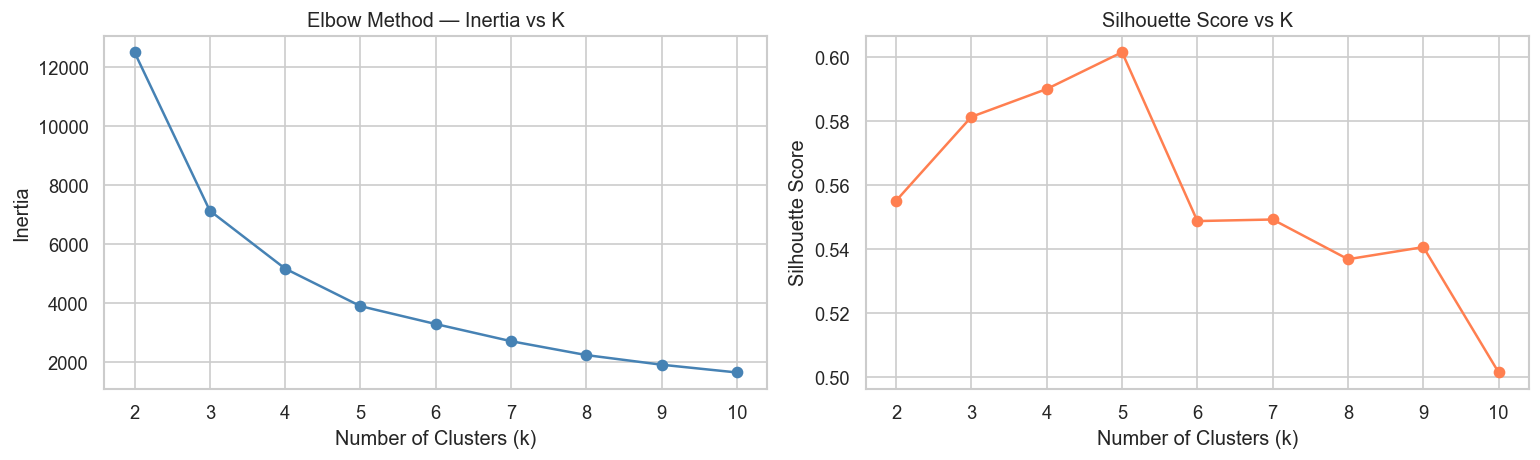

In [6]:
# Scale the raw RFM values before clustering — K-Means is distance-based
# so unscaled Monetary values (hundreds to thousands) would dominate Recency and Frequency.

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

inertia    = []
silhouette = []
k_range    = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, inertia, marker='o', color='steelblue')
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette, marker='o', color='coral')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

## 5. Final K-Means Model (k=5)

We fit the final model at k=5, attach the cluster labels back to the RFM
table, and profile each cluster by its mean Recency, Frequency, and Monetary
values to understand what each cluster represents.

In [7]:
# Fit final model at the optimal k identified above.
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

# Profile each cluster using original (unscaled) values for interpretability.
cluster_profile = (
    rfm.groupby('Cluster')
    .agg(
        Customers = ('Customer ID', 'count'),
        Recency   = ('Recency',     'mean'),
        Frequency = ('Frequency',   'mean'),
        Monetary  = ('Monetary',    'mean')
    )
    .round(1)
    .sort_values('Monetary', ascending=False)
)

print(cluster_profile)

         Customers  Recency  Frequency  Monetary
Cluster                                         
2                4      3.5      204.8  423256.0
4               24     22.5      118.5   98002.9
3              365     27.3       28.9   13676.8
0             3564     75.7        5.1    1878.4
1             1905    471.3        2.2     710.8


## 6. Cluster Labels & Save

Each cluster is assigned a descriptive label based on its profile.
The final table merges rule-based RFM segments with K-Means clusters,
giving us two complementary views of the customer base.

In [8]:
# Labels derived directly from the cluster profile above.
cluster_labels = {
    2: 'Mega Accounts',
    4: 'High Value Regulars',
    3: 'Mid Tier Actives',
    0: 'Low Spend Majority',
    1: 'Dormant'
}

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)

# Final column overview before saving
print('Segment distribution:')
print(rfm['Segment'].value_counts())
print('\nCluster distribution:')
print(rfm['Cluster_Label'].value_counts())

rfm.to_parquet(SAVE_PATH, index=False)
print(f'\nSaved: {SAVE_PATH}')
print(f'Shape: {rfm.shape}')

Segment distribution:
Segment
Champions              1477
Loyal Customers        1212
Lost                   1084
Hibernating             618
At Risk                 551
Recent Customers        451
Potential Loyalists     380
Cannot Lose Them         89
Name: count, dtype: int64

Cluster distribution:
Cluster_Label
Low Spend Majority     3564
Dormant                1905
Mid Tier Actives        365
High Value Regulars      24
Mega Accounts             4
Name: count, dtype: int64

Saved: E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\rfm_segments.parquet
Shape: (5862, 11)
